In [9]:
using Revise
using ECCOtour, MeshArrays, 
      MITgcmTools, JLD2, 
      LaTeXStrings
using PythonCall
import PythonPlot as plt

sns = pyimport("seaborn")
include("../src/config_exp.jl");

In [30]:
runpath,diagpath = listexperiments(exprootdir());

tecco = range(1992,step=1/12,stop=2018)
ocean_mask = wet_pts(Γ)
area = readarea(γ);
area32 = Float32.(area)

cell_depths = get_cell_thickness(ocean_mask, ΔzF, Γ.hFacC); 
cell_volumes = get_cell_volumes(area, cell_depths);

Available experiments are
interannual_eqpac
iter129_bulkformula
noinitadjust
nosfcadjust
nointerannual_buoyancy
nointerannual_wind
interannual_southpac
climatological_tau
seasonalclimatology_iter0
add_sigma1_windstresscurl.m
iter0_bulkformula
nointerannual_eqpac
interannual_southpac_cora
checkout_plots.m
iter129_fluxforced
interannual_northpac
nointerannual
compare_timeseries.m


In [27]:
#define experimennt
expname = "iter129_bulkformula"
get_data_files(xx, expname) = filter(x -> occursin("data",x),searchdir(diagpath[expname],xx))

#define the file names
datafilelist_uvw  = get_data_files("trsp_3d_set1", expname);

#specify time-step
tt = 200
fnameuvw = datafilelist_uvw[tt]
u, v, w = extract_eulerian_velocities(diagpath, expname, fnameuvw, γ);

In [23]:
Utrsp, Vtrsp = UVtoTrsp(u, v, Γ, γ)
Wtrsp = w .* area32;

UV_conv3D = MeshArray(γ,Float32,50);
W_conv3D = MeshArray(γ,Float32,50);

calc_UV_conv3D!(Utrsp, Vtrsp, UV_conv3D); #horizontal diffusive converegence
calc_W_conv3D!(Wtrsp, W_conv3D) #vertical diffusive converegence


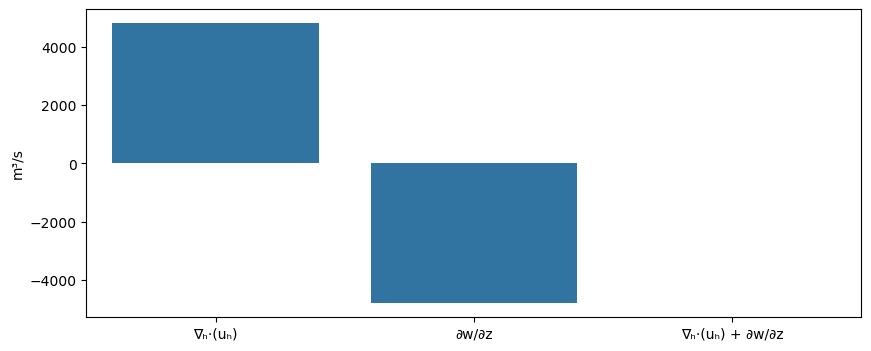

In [26]:
select_cell(x) = x[4, 20][110, 45]

vars = [select_cell(UV_conv3D), 
        select_cell(W_conv3D)] 
push!(vars, sum(vars))
labels = ["∇ₕ⋅(uₕ)", "∂w/∂z", "∇ₕ⋅(uₕ) + ∂w/∂z"]

fig, ax = plt.subplots(figsize = (10, 4))
sns.barplot(x=labels, y=vars, ax = ax)
ax.set_ylabel("m³/s")
fig